
# Lab 6: FEM 1D

### Exercise 1: Use FEM 1D to solve the EDO

Use FEM to solve the next EDO (improve the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
-\dfrac{d^2y}{dx^2}=xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(2-x)-x
\end{equation}

N =  5   Error máximo = 3.330669e-16
N = 10   Error máximo = 5.134781e-16
N = 20   Error máximo = 5.273559e-16
N = 40   Error máximo = 7.494005e-16


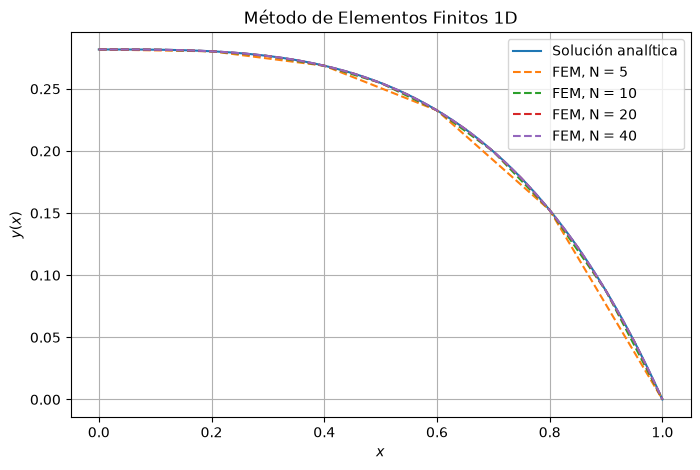

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Problema
a = 0
b = 1
Ua = 3 - np.e
Ub = 0

def f(x):
    return x*np.exp(x)

def exact(x):
    return 1 - np.e + np.exp(x)*(2-x) - x


# Valores de N 
Ns = [5, 10, 20, 40]

# Solución exacta
x_exact = np.linspace(a, b, 300)

plt.figure(figsize=(8,5))
plt.plot(x_exact, exact(x_exact), label='Solución analítica')

# Resolver FEM para cada N
for N in Ns:

    # Malla
    h = (b-a)/N
    x = np.linspace(a, b, N+1)

    # Matriz y vector
    A = np.zeros((N+1, N+1))
    rhs = np.zeros(N+1)

    # Ensamblaje
    for i in range(N):

        x1 = x[i]
        x2 = x[i+1]

        # Matriz de rigidez
        A[i,i] += 1/h
        A[i,i+1] += -1/h
        A[i+1,i] += -1/h
        A[i+1,i+1] += 1/h

        # Funciones de forma
        phi1 = lambda xx: (x2-xx)/(x2-x1)
        phi2 = lambda xx: (xx-x1)/(x2-x1)

        # Vector de carga
        rhs[i] += quad(
            lambda xx: f(xx)*phi1(xx),
            x1, x2
        )[0]

        rhs[i+1] += quad(
            lambda xx: f(xx)*phi2(xx),
            x1, x2
        )[0]

    # Condiciones de frontera
    rhs = rhs - A[:,0]*Ua - A[:,-1]*Ub

    A[0,:] = 0
    A[:,0] = 0
    A[0,0] = 1

    A[-1,:] = 0
    A[:,-1] = 0
    A[-1,-1] = 1

    rhs[0] = Ua
    rhs[-1] = Ub

    # Solución
    y = np.linalg.solve(A, rhs)

    # Interpolación para graficar
    x_new = np.linspace(a, b, 300)
    y_new = np.interp(x_new, x, y)

    plt.plot(x_new, y_new, '--',
             label=f'FEM, N = {N}')

    # Error máximo en los nodos
    error = np.max(np.abs(y - exact(x)))

    print(f'N = {N:2d}   Error máximo = {error:.6e}')


plt.xlabel(r'$x$')
plt.ylabel(r'$y(x)$')
plt.title('Método de Elementos Finitos 1D')

plt.legend()
plt.grid()
plt.show()